# INFO284 Semester assignment

In this section we will import libraries for data preprocessing and model implementation.
Scikit-learn is used for traditional classifiers (Naive Bayes and Logistic Regression), and TensorFlow/Keras for the LSTM model.

In [144]:
import pandas as pd 
import re

import matplotlib.pyplot as plt

#Naive bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

#Logistic regression
import numpy as np
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression

#LSTM Model
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout





## Retrieving the Dataset


In this section, the dataset is loaded from a CSV file using pandas. A copy of the original dataframe is created to ensure that preprocessing steps do not modify the raw data. This ensures reproducibility, protects the raw data, and allows comparison between the original and cleaned versions of the dataset.

The df.head() method is used to preview the first observations of the dataset.
This helps verify that the data has been loaded correctly and provides an initial understanding of the variables and their structure.

In [145]:
df_original = pd.read_csv("reviews.csv")
df = df_original.copy()
df.head()

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1


## Data Analysis

The Review.cvs dataset contains 6,210 rows and 5 columns.
review_id
Uses a universal unique identifier (UUID) for each review. This is not useful for prediction, but it is useful for tracking records.

rating
The rating column contains the numerical score for each review, ranging from 1 to 5 stars. This variable can later be used as the target variable to predict an outcome. Or the ratings can be converted into sentiment labels (positive or negative) for a classification task.

review_text
This column contains the actual text of each review. It is the main feature in the dataset and will be the primary focus for modeling. Since it contains natural language  the text needs to be cleaned and converted into numerical numbers before it can be used in modeling.

review_date
This column shows the date and time when the review was posted. It is not necessary for basic text classification tasks, but it could be useful for timebased analysis for example studying trends or changes in sentiment over time. (if we are going to analyzde that)

helpful
This column contains numerical value representation of the number of helpful votes each review has received. Helpful can be used as a feature in the model or as a separate prediction target to evaluate whether a review is considered useful or not.

### Rating distribution

The rating variable ranges from 1 to 5, representing user scores from lowest to highest satisfaction. Before applying any preprocessing steps, we visualized the distribution of these ratings to examine how reviews are distributed across the five classes. This helps assess potential class imbalance and better understand the structure of the target variable prior to modeling.

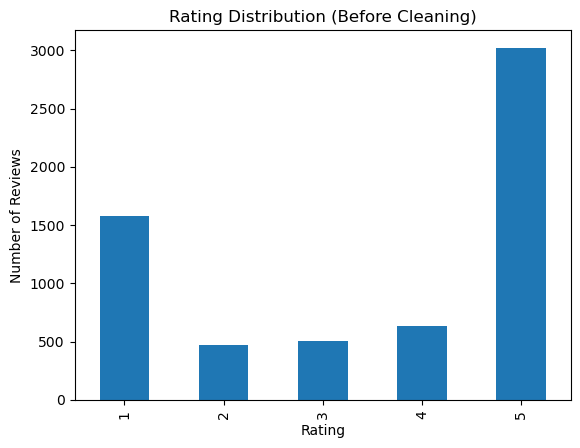

In [146]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure()
rating_counts.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution (Before Cleaning)")
plt.show()

## Text length distribution

In text classification tasks, the length of the input text can influence model performance. Short reviews may contain limited contextual information, making it more difficult for the model to correctly predict the rating. Conversely, longer reviews often provide richer semantic information, which may improve classification accuracy.

By analyzing the distribution of review lengths, we gain insight into the variability of the textual data. This helps us understand whether the dataset contains extremely short or extremely long reviews, which may affect feature extraction (e.g., TF-IDF representation) and model generalization.

Additionally, identifying outliers in text length can inform potential preprocessing decisions, such as removing unusually short reviews that may not contain meaningful information.

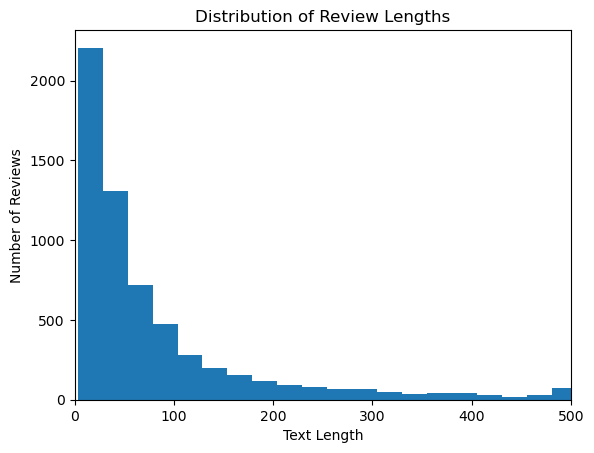

In [147]:
df["text_length"] = df["review_text"].apply(len)

plt.figure()
plt.hist(df["text_length"], bins=50)
plt.xlabel("Text Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")
plt.xlim(0, 500)
plt.show()

The distribution of review lengths is heavily right-skewed. Most reviews are relatively short, while a smaller number of reviews are substantially longer. This long-tail distribution is common in user-generated text data.

The presence of very short reviews may limit the amount of contextual information available to the model, whereas longer reviews may contain richer semantic signals. Extreme outliers in text length could potentially influence feature extraction and may require further inspection.

In [148]:

# 2) Rens litt: sørg for string og fjern whitespace
s = df["review_date"].astype(str).str.strip()

# 3) Prøv først "norsk/europeisk" format DD/MM/YYYY HH:MM
dt1 = pd.to_datetime(s, format="%d/%m/%Y %H:%M", errors="coerce")

# 4) For de som feilet: prøv ISO / "vanlig" parsing (Pandas gjetter)
mask = dt1.isna()
dt2 = pd.to_datetime(s[mask], errors="coerce", dayfirst=True)

# 5) Kombiner resultatene
dt = dt1.copy()
dt[mask] = dt2

# 6) Sett tilbake i df
df["review_date_parsed"] = dt

# 7) Sjekk hvor mange som fortsatt feiler (skal være lavt)
print("Totalt rader:", len(df))
print("Feilet parsing:", df["review_date_parsed"].isna().sum())

# 8) Tell per dag (bruk datetime-indeks + resample)
daily_counts = (
    df.dropna(subset=["review_date_parsed"])
      .set_index("review_date_parsed")
      .resample("D")
      .size()
      .reset_index(name="number_of_reviews")
)

daily_counts

Totalt rader: 6210
Feilet parsing: 0


/var/folders/5y/4dsjd8m12vs___jlknnplrpr0000gn/T/ipykernel_72563/1396688062.py:9: UserWarning: Parsing dates in %m/%d/%Y %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt2 = pd.to_datetime(s[mask], errors="coerce", dayfirst=True)


,review_date_parsed,number_of_reviews
0,2025-11-21,402
1,2025-11-22,1177
2,2025-11-23,1169
3,2025-11-24,1117
4,2025-11-25,1270
5,2025-11-26,1075


/var/folders/5y/4dsjd8m12vs___jlknnplrpr0000gn/T/ipykernel_72563/248835024.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_day.set_index("review_date_parsed").resample("H").size()


<Axes: xlabel='review_date_parsed'>

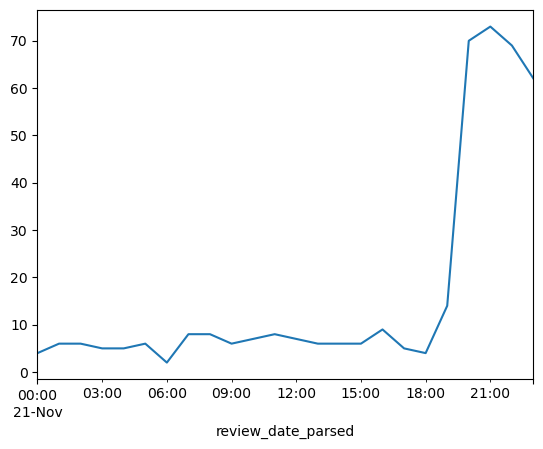

In [149]:
df_day["review_date_parsed"].min()
# Filtrer én dag
df_day = df[df["review_date_parsed"].dt.date == pd.to_datetime("2025-11-21").date()]

# Tell per time
hourly = df_day.set_index("review_date_parsed").resample("H").size()

# Plot
hourly.plot()

### Correlation Matrix

We chose to use a correlation matrix as part of the exploratory data analysis to examine linear relationships between numerical variables in the dataset. Since the original dataset mainly contains textual information, additional numerical features were engineered (e.g., word count, text length, punctuation frequency and time-based features). This allows us to investigate how structural properties of the reviews relate to the assigned rating. The matrix also helps identify redundant features and potential multicollinearity before model training. 

             rating  helpful  char_count  word_count  excl_count  review_hour
rating         1.00     0.01       -0.24       -0.26       -0.08        -0.03
helpful        0.01     1.00        0.04        0.04       -0.00        -0.01
char_count    -0.24     0.04        1.00        0.95        0.09        -0.03
word_count    -0.26     0.04        0.95        1.00        0.11        -0.03
excl_count    -0.08    -0.00        0.09        0.11        1.00         0.01
review_hour   -0.03    -0.01       -0.03       -0.03        0.01         1.00


/var/folders/5y/4dsjd8m12vs___jlknnplrpr0000gn/T/ipykernel_72563/2754991032.py:7: UserWarning: Parsing dates in %m/%d/%Y %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce", dayfirst=True)


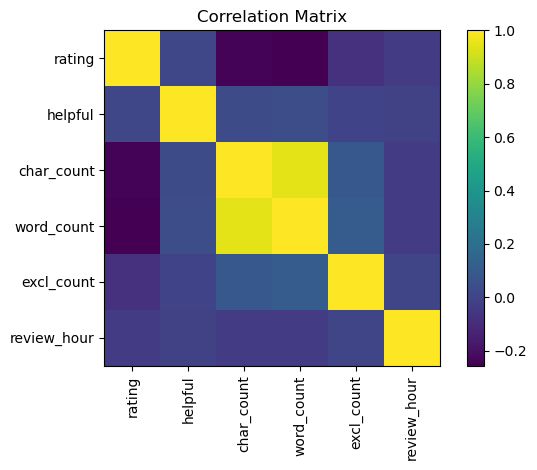

In [150]:
# --- Enkle tekst-features ---
df["char_count"] = df["review_text"].str.len()
df["word_count"] = df["review_text"].str.split().str.len()
df["excl_count"] = df["review_text"].str.count("!")

# --- Dato-features ---
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce", dayfirst=True)
df["review_hour"] = df["review_date"].dt.hour

# --- Korrelasjonsmatrise ---
corr = df[[
    "rating",
    "helpful",
    "char_count",
    "word_count",
    "excl_count",
    "review_hour"
]].corr()

print(corr.round(2))

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


The correlation analysis shows a strong positive relationship between word count and character count, indicating redundancy between these features. A moderate positive correlation was observed between sentiment-related features and rating, suggesting that textual tone aligns with the assigned score. Complaint-related indicators display a negative correlation with rating, which is consistent with intuitive expectations. Time-based features show little correlation with rating, indicating limited predictive value. Overall, the matrix confirms logical relationships in the data and informs subsequent feature selection. (Må nok endre denne senere)

## Data Cleaning

### Removing Columns ?

The feature helpful captures post-publication user feedback rather than textual content itself. As the goal of this task is to predict the review rating based on review content, it is important to evaluate whether including helpful is conceptually appropriate. We therefore examine its distribution and statistical relationship with rating to determine whether it adds predictive value or risks introducing information that is not directly derived from the review text.

In [151]:
#Teller hvor mange ganger hver verdi av «helpful» forekommer
print(df["helpful"].value_counts())

#Returnerer prosentandel av det ovenfor
print(df["helpful"].value_counts(normalize=True))


helpful
0         4939
1          987
2          127
3           34
5           12
6           12
4           12
8            7
12           6
9            6
11           4
16           4
14           4
7            4
17           3
10           3
23           3
15           2
44           2
29           2
36           2
18           2
13           2
45           1
20           1
28           1
82           1
1688         1
248962       1
19           1
1884         1
33           1
4345         1
47           1
48           1
76           1
38           1
26           1
305          1
188          1
8696         1
42           1
70           1
56           1
22           1
80           1
34           1
191          1
101          1
67           1
30           1
95           1
113          1
121          1
Name: count, dtype: int64
helpful
0         0.795330
1         0.158937
2         0.020451
3         0.005475
5         0.001932
6         0.001932
4         0.001932
8         0.001

In [152]:
#Sjekker gjennomsnitt for både de med helpful = 0 og de med helpful > 0
df["helpful"].describe()

(df["helpful"] == 0).mean()          # andel nuller
(df["helpful"] > 0).mean()           # andel med minst 1
df["helpful"].value_counts().head(15)


helpful
0     4939
1      987
2      127
3       34
5       12
6       12
4       12
8        7
12       6
9        6
11       4
16       4
14       4
7        4
17       3
Name: count, dtype: int64

In [153]:
#Regner ut Pearson-korrelasjon mellom rating og helpful
df[["rating", "helpful"]].corr(numeric_only=True)

df.groupby(df["helpful"] > 0)["rating"].mean()     # sammenlign 0 vs >0
df.groupby(df["helpful"] > 0)["rating"].value_counts(normalize=True)


helpful  rating
False    5         0.523385
         1         0.252480
         4         0.087062
         3         0.069245
         2         0.067827
True     5         0.343037
         1         0.263572
         4         0.158930
         3         0.130606
         2         0.103855
Name: proportion, dtype: float64

Drøfte hva vi fant ut av ovenfor og om vi skal fjerne helpful

In [154]:
#This filter removes reviews containing unusually long single words, which are often spam or noise, improving data quality for text analysis.

#Number of reviews before filtering
before_count = len(df)
df = df[~df["review_text"].str.split().apply(

     lambda words: any(len(word) > 15 for word in words)

 )]
   
# Number of reviews after filtering
after_count = len(df)
 
# Number of reviews removed in filtering
removed_count = before_count - after_count
 
print("Before filtering:", before_count)
print("After removing excessive characters:", after_count)
print("Removed:", removed_count)


Before filtering: 6210
After removing excessive characters: 5713
Removed: 497


In [155]:
# Filter for removing repeating words

# Count before filtering
before_count2 = len(df)

# Regex pattern for 3+ repeated consecutive words
pattern2 = r'\b(\w+)\b(?=\s+\1\b\s+\1\b)'

# Identify rows to remove
mask = df["review_text"].str.contains(pattern2, case=False, regex=True, na=False)

removed_count2 = mask.sum()

# Filter dataset
df_clean = df[~mask]

after_count2 = len(df_clean)

# Print results
print(f"Total reviews before filtering: {before_count2}")
print(f"Reviews removed: {removed_count2}")
print(f"Total reviews after filtering: {after_count2}")



Total reviews before filtering: 5713
Reviews removed: 185
Total reviews after filtering: 5528


/var/folders/5y/4dsjd8m12vs___jlknnplrpr0000gn/T/ipykernel_72563/2246965277.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df["review_text"].str.contains(pattern2, case=False, regex=True, na=False)


## 21.2025


In [156]:
# 2) Rens litt: sørg for string og fjern whitespace
s = df["review_date"].astype(str).str.strip()

# 3) Prøv først "norsk/europeisk" format DD/MM/YYYY HH:MM
dt1 = pd.to_datetime(s, format="%d/%m/%Y %H:%M", errors="coerce")

# 4) For de som feilet: prøv ISO / "vanlig" parsing (Pandas gjetter)
mask = dt1.isna()
dt2 = pd.to_datetime(s[mask], errors="coerce", dayfirst=True)

# 5) Kombiner resultatene
dt = dt1.copy()
dt[mask] = dt2

# 6) Sett tilbake i df
df["review_date_parsed"] = dt

# 7) Sjekk hvor mange som fortsatt feiler (skal være lavt)
print("Totalt rader:", len(df))
print("Feilet parsing:", df["review_date_parsed"].isna().sum())

# 8) Tell per dag (bruk datetime-indeks + resample)
daily_counts = (
    df.dropna(subset=["review_date_parsed"])
      .set_index("review_date_parsed")
      .resample("D")
      .size()
      .reset_index(name="number_of_reviews")
)

daily_counts

Totalt rader: 5713
Feilet parsing: 374


/var/folders/5y/4dsjd8m12vs___jlknnplrpr0000gn/T/ipykernel_72563/981357212.py:9: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt2 = pd.to_datetime(s[mask], errors="coerce", dayfirst=True)


,review_date_parsed,number_of_reviews
0,2025-11-21,256
1,2025-11-22,1029
2,2025-11-23,1028
3,2025-11-24,975
4,2025-11-25,1124
5,2025-11-26,927


/var/folders/5y/4dsjd8m12vs___jlknnplrpr0000gn/T/ipykernel_72563/248835024.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_day.set_index("review_date_parsed").resample("H").size()


<Axes: xlabel='review_date_parsed'>

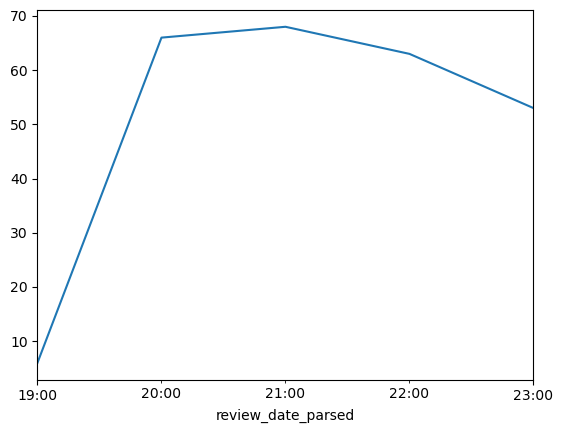

In [157]:
df_day["review_date_parsed"].min()
# Filtrer én dag
df_day = df[df["review_date_parsed"].dt.date == pd.to_datetime("2025-11-21").date()]

# Tell per time
hourly = df_day.set_index("review_date_parsed").resample("H").size()

# Plot
hourly.plot()

## Feature filtering

In [158]:
# Remove irrelevant features not needed for the model
df = df.drop(columns=["review_id", "review_date", "helpful"])
df.head()

,rating,review_text,text_length,review_date_parsed,char_count,word_count,excl_count,review_hour
0,5,It's good,9,2025-11-22 01:19:00,9,2,0,1.0
1,5,WhatsApp not working well always shows offline...,73,2025-11-24 20:03:00,73,12,0,20.0
2,5,"Oppo not corresponding, share with me the offi...",63,2025-11-25 06:26:00,63,10,0,6.0
3,5,"Excellent app, great communication super conne...",109,2025-11-25 18:09:00,109,14,0,18.0
4,4,simply the ɓest for chat and calls.i love it,44,2025-11-24 01:10:00,44,9,0,1.0


## Machine Learning models

### Model 1: Multinomial Naive Bayes

In [159]:
X = df["review_text"]
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# https://www.geeksforgeeks.org/machine-learning/multinomial-naive-bayes/ kilde inspo 

Accuracy: 0.621172353455818
              precision    recall  f1-score   support

           1       0.54      0.61      0.58       287
           2       0.00      0.00      0.00        79
           3       0.14      0.01      0.02        77
           4       0.14      0.02      0.03       110
           5       0.67      0.90      0.77       590

    accuracy                           0.62      1143
   macro avg       0.30      0.31      0.28      1143
weighted avg       0.50      0.62      0.54      1143



### Model 2: Logistic Regression 

In [160]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_vec, y_train)

y_pred_log = log_model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# https://www.w3schools.com/python/python_ml_logistic_regression.asp
# Reshaped for Logistic function.

Accuracy: 0.6307961504811899
              precision    recall  f1-score   support

           1       0.55      0.67      0.60       287
           2       0.00      0.00      0.00        79
           3       0.00      0.00      0.00        77
           4       0.00      0.00      0.00       110
           5       0.67      0.90      0.76       590

    accuracy                           0.63      1143
   macro avg       0.24      0.31      0.27      1143
weighted avg       0.48      0.63      0.55      1143



/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [161]:
vocab_size = 20000     
max_len = 200           
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

classes = np.sort(y_train.unique())
num_classes = len(classes)


class_to_index = {c: i for i, c in enumerate(classes)}
y_train_idx = y_train.map(class_to_index).to_numpy()
y_test_idx = y_test.map(class_to_index).to_numpy()

embedding_dim = 128

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print("\n--- LSTM model summary ---")
lstm_model.summary()



early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_pad, y_train_idx,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


test_loss, test_acc = lstm_model.evaluate(X_test_pad, y_test_idx, verbose=0)
print("\n--- LSTM Text Classifier ---")
print("Accuracy:", test_acc)


y_pred_probs = lstm_model.predict(X_test_pad, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)


index_to_class = {i: c for c, i in class_to_index.items()}
y_pred_lstm = np.array([index_to_class[i] for i in y_pred_idx])

print(classification_report(y_test, y_pred_lstm))

# https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-lstm-rnn-in-tensorflow/

/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



--- LSTM model summary ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.4841 - loss: 1.3633 - val_accuracy: 0.5088 - val_loss: 1.3125
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5055 - loss: 1.3166 - val_accuracy: 0.5088 - val_loss: 1.3084
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.5066 - loss: 1.3015 - val_accuracy: 0.5088 - val_loss: 1.3072
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.5057 - loss: 1.3075 - val_accuracy: 0.5088 - val_loss: 1.3082
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5066 - loss: 1.3043 - val_accuracy: 0.5088 - val_loss: 1.3065
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.5071 - loss: 1.3031 - val_accuracy: 0.5088 - val_loss: 1.3088
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5068 - loss: 1.2957 - val_accuracy: 0.5088 - val_loss: 1.3146

--- LSTM Text Classifier ---
Accuracy: 0.516185462474823
              precision    recall  f1-score   support

/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Info180/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res